<img src = "https://drive.google.com/uc?export=view&id=1rSrsZ04aJ_D3BC67Cy2dBUZ6tmguydNf" alt = "Encabezado MLDS" width = "100%">  </img>

# **Preparación de los datos**
---

Este notebook es una plantilla que le puede servir como guía para el tercer entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**JESUS DAVID ESCOBAR DIZZ**
2. ---**JUAN DAVID TULANDE GUTIERREZ**---
3. ---**DIANA CELIA ZAMBRANO PINTO**---

Como primer paso se importa y unifica la informacion, tambien se importan las librerias necesarias

In [ ]:
#LIBRERIAS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#IMPORTAR INFORMACION
url = "https://github.com/jdizz0414/Data/raw/refs/heads/main/Eventos%20en%20Salud%202025%20en%20Crudo.xlsx"

df = pd.read_excel(url,dtype={"código divipola": str,"código divipola.1": str, "CIE-10": str})
df = df.rename(columns={ "fecha de registro": "FECHA REGISTRO","código divipola": "COD DIVIPOLA DEPARTAMENTO",
                        "departamento": "DEPARTAMENTO","código divipola.1": "COD DIVIPOLA MUN",
                        "municipio": "MUNICIPIO", "municipio": "MUNICIPIO",
                         "sistema": "SISTEMA", "entidad reporta": "ENTIDAD REPORTA"})
url2 = "https://github.com/jdizz0414/Data/raw/refs/heads/main/Tabla%20auxiliar%20COD%20CIE10.xlsx"

df_aux = pd.read_excel(url2,dtype={"codigo_cie10 	": str,"mortalidad_1_5": str})
df_aux = df_aux.rename(columns={ "codigo_cie10": "CIE-10","enfermedad": "NOMBRE","contagiosa": "CONTAGIOSA",
                         "cronica": "CRONICA", "mortalidad_1_5": "MORTALIDAD"})

In [ ]:
#UNIFICAR FUENTES DE INFORMACION
df_compacto = df.merge(df_aux[["CIE-10","GRUPO","CONTAGIOSA", "CRONICA", "MORTALIDAD"]],on="CIE-10",how="left")
df_compacto.head()

,FECHA REGISTRO,COD DIVIPOLA DEPARTAMENTO,DEPARTAMENTO,COD DIVIPOLA MUN,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD
0,2025-01-07,08,ATLÁNTICO,08001,BARRANQUILLA,M199,"ARTROSIS, NO ESPECIFICADA",OTRAS ARTROSIS,RIPS,INS,ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL T...,No,Si,1
1,2025-01-10,08,ATLÁNTICO,08001,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
2,2025-01-13,08,ATLÁNTICO,08001,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
3,2025-01-24,08,ATLÁNTICO,08001,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,INS,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
4,2025-01-24,08,ATLÁNTICO,08001,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1


## **1. Limpieza de los Datos**
---

La elección de las técnicas de preprocesamiento puede diferir en cada conjunto de datos. Recuerde que es posible aplicar, según sea necesario (no necesariamente todas), las técnicas generales que se han explorado en el curso. La elección dependerá del tipo de datos con el que esté trabajando.

A lo largo de esta entrega, busque responder las siguientes preguntas:

- ¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía en el conjunto de datos durante el proceso de limpieza?

Para cada tipo de anomalía se usó un criterio distinto porque su naturaleza es distinta: los faltantes se identificaron con isna() sobre las columnas clave (CIE-10, NOMBRE, DESCRIPCION); los duplicados con duplicated() sobre la totalidad de las columnas (coincidencia exacta fila a fila); los atípicos se trataron como categorías de muy baja frecuencia relativa en municipio (no como valores numéricos extremos, porque no hay variables numéricas continuas en este dataset — todo es categórico, de fecha o de código); las inconsistencias se buscaron como problemas de formato/codificación de texto (caracteres corruptos); y lo corrupto se buscó como valores que no encajan con la estructura esperada de una columna (por ejemplo, un código CIE-10 con un formato distinto al resto).

- ¿Cómo se justificaría la necesidad de cada paso de preprocesamiento en términos de mejora de la calidad de los datos y preparación para el análisis subsiguiente?

Cada paso enfrenta un riesgo en la calidad distina: los faltantes y corruptos amenazan la completitud; los duplicados amenazan la unicidad (pueden inflar frecuencias y sesgar proporciones); las inconsistencias de formato amenazan la uniformidad (dificultan agrupar/filtrar correctamente, por ejemplo si "BOGOT?" y "BOGOTÁ " se tratan como categorías distintas); y la selección de variables (1.6) amenaza la relevancia lo cual se evita al cargar el análisis con columnas redundantes o sin valor interpretativo. Los cuatro tipos de limpieza son necesarios para evitar una conclusión equivocada con apariencia de rigor.


### **1.1. Valores faltantes**
---
Al encontrarnos con valores faltantes en el conjunto de datos, es crucial preguntarse:

* ¿Cómo afectan estos valores a la integridad y representatividad de la información?

Se identificaron 19 registros con valores faltantes dentro del conjunto de datos. Debido al tamaño total del dataset (415.154 filas) estos registros representan una proporción muy pequeña (apenas el 0,0046%) y no es representativa del conjunto de información, por lo que su impacto sobre la integridad y representatividad general de los datos es limitado.

Vale la pena indicar que no son un faltante aleatorio. 18 de los 19 casos se concentran en un mismo municipio (Buenaventura, Valle del Cauca) durante un rango de fechas muy acotado (del 4 al 29 de septiembre de 2025). Eso sugiere un problema puntual de reporte en ese municipio y ese periodo pero que no afecta la representatividad del dataset completo, pero si en algún momento se hiciera un análisis específico de Buenaventura o de septiembre de 2025, sí convendría tenerlo presente.

* ¿Cómo se identificaron los valores faltantes en el conjunto de datos?

Con isna() sobre las columnas CIE-10, NOMBRE y DESCRIPCION (las que definen de qué se trata el evento). No se buscaron faltantes fila por fila "a ojo" sino que se usó el conteo programático, que es reproducible y no depende de la revisión manual.

* ¿Cuáles fueron los criterios para decidir si rellenar con valores estimados o eliminar los valores faltantes? En caso que aplique, ¿qué método de relleno se utilizó y por qué se consideró apropiado?

Para decidir el tratamiento de estos registros se tuvo en cuenta que las variables del conjunto de datos son categóricas. Por esta razón, no se consideró apropiado realizar una imputación mediante medidas estadísticas como la media o la mediana. Aunque para variables categóricas podría utilizarse la moda u otros métodos de imputación, en este caso se optó por excluir los registros con valores faltantes, debido a que son únicamente 19 observaciones y su eliminación no representa una pérdida significativa de información.

* ¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave? Por ejemplo, si hay valores faltantes en una variable crítica, ¿cómo podría afectar la interpretación de los resultados?

Si, el 100% de los faltantes están concentrados en un solo municipio y en un rango corto de fechas, lo cual sí se documenta como hallazgo sin embargo, no cambia la decisión de eliminarlos.

Esta decisión no afecta de manera relevante la interpretación de los resultados ni la representatividad del conjunto de datos.En consecuencia, los 19 registros con información faltante serán excluidos de los análisis posteriores, manteniendo únicamente las observaciones con información completa y válida.

In [ ]:
### REGISTROS CON DATOS FALTANTES:

# Faltantes por columna
print("Faltantes por columna en df_compacto:")
print(df_compacto[["CIE-10", "NOMBRE", "DESCRIPCION"]].isna().sum())

# El conteo correcto es el de filas con AL MENOS un faltante entre estas tres columnas
mask_faltantes = df_compacto[["CIE-10", "NOMBRE", "DESCRIPCION"]].isna().any(axis=1)
print(f"\nTotal de registros con algún faltante: {mask_faltantes.sum()} de {len(df_compacto)} "
      f"({mask_faltantes.mean()*100:.4f}%)")

# Distribución de esos faltantes por municipio y por mes
faltantes = df_compacto[mask_faltantes]
print("\nMunicipio de los registros con faltante:")
print(faltantes["MUNICIPIO"].value_counts())
print("\nRango de fechas de los registros con faltante:")
print(faltantes["FECHA REGISTRO"].min(), "-", faltantes["FECHA REGISTRO"].max())

Faltantes por columna en df_compacto:
CIE-10         18
NOMBRE         19
DESCRIPCION    19
dtype: int64

Total de registros con algún faltante: 19 de 415154 (0.0046%)

Municipio de los registros con faltante:
MUNICIPIO
BUENAVENTURA    18
BOGOTÁ, D.C.     1
Name: count, dtype: int64

Rango de fechas de los registros con faltante:
2025-08-13 10:15:00 - 2025-09-29 19:00:00


In [ ]:
#ELIMINAR LOS REGISTROS CON DATOS FALTANTES DEL DATASET
df_paso1 = df_compacto.dropna(subset=["CIE-10", "NOMBRE", "DESCRIPCION"])
print(f"Filas antes: {len(df_compacto)}  ->  después de eliminar faltantes: {len(df_paso1)} "
      f"(se eliminaron {len(df_compacto) - len(df_paso1)})")

Filas antes: 415154  ->  después de eliminar faltantes: 415135 (se eliminaron 19)


In [ ]:
#CORROBORAR QUE NO SE PRESENTEN DATOS FALTANTES
df_paso1["CIE-10"].isna().sum()
df_paso1[df_paso1[["CIE-10"]].isna().any(axis=1)]


,FECHA REGISTRO,COD DIVIPOLA DEPARTAMENTO,DEPARTAMENTO,COD DIVIPOLA MUN,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD


### **1.2. Valores duplicados**
----
Ante la presencia de valores duplicados, es esencial reflexionar sobre su impacto en los resultados.

* ¿Cómo se identificaron y manejaron los valores duplicados en el conjunto de datos?

Se identificó un volumen crítico de 78.896 filas duplicadas exactas, equivalente al 19,00 % del total del conjunto de datos. Estos registros corresponden a datos de salud que presentan coincidencia exacta en variables relevantes como fecha, ubicación, diagnóstico y entidad, por lo que se consideraron registros repetidos y no observaciones independientes.

* ¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?

Para su identificación se realizó una búsqueda de duplicados exactos considerando la totalidad de las variables del registro. Debido a que las filas presentan una coincidencia completa, no fue necesario establecer criterios diferenciados para determinar si dos registros correspondían al mismo evento.

* ¿Pueden estos duplicados sesgar el análisis, y en qué medida?

La presencia de estos duplicados puede sesgar el análisis, especialmente en el cálculo de frecuencias, proporciones y distribución de los diagnósticos, ya que un mismo evento podría contabilizarse varias veces. Al representar el 19,00 % de los registros, su impacto potencial se considera significativo y podría generar una sobreestimación de determinadas categorías.

* ¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?

Se justifica la eliminación de los duplicados exactos, con el objetivo de mantener la coherencia, integridad y singularidad de los registros. La eliminación se limita exclusivamente a observaciones completamente duplicadas, evitando eliminar registros que puedan representar eventos diferentes aunque compartan algunas características.

* ¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?

Para asegurar que la eliminación no afecte negativamente la representación del conjunto de datos, se debe verificar que los registros eliminados sean realmente duplicados exactos y comparar las distribuciones de las principales variables antes y después de la depuración. De esta manera, se garantiza que el proceso reduzca la redundancia sin modificar la estructura o composición de la información.

La identificación y eliminación de duplicados busca asegurar que cada registro aporte información única y valiosa.

In [ ]:
#REGISTROS DUPLICADOS
df_paso2 = df_paso1.drop_duplicates()
print(f"\nFilas antes: {len(df_paso1)}  ->  después de eliminar duplicados: {len(df_paso2)} "
      f"(se eliminaron {len(df_paso1) - len(df_paso2)})")


Filas antes: 415135  ->  después de eliminar duplicados: 360713 (se eliminaron 54422)


Para el analisis del conjunto de datos, las variables CONTAGIOSA, CRONICA,MORTALIDAD son critica por eso se hace relevante mirar gráficamente su distribución antes y después de la eliminación de los registros duplicados debido a que este proceso implica eliminar una cantidad importante de información

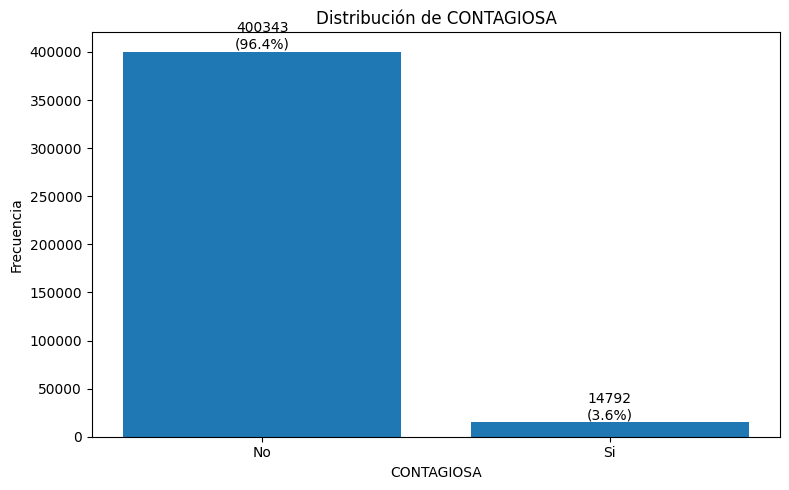

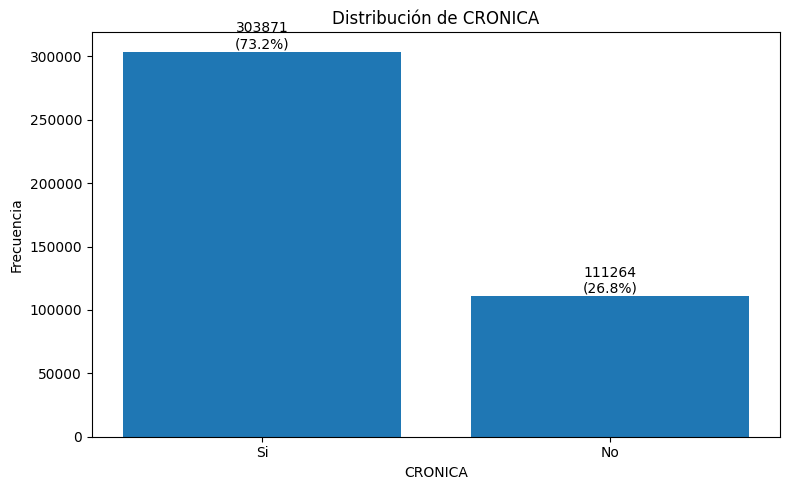

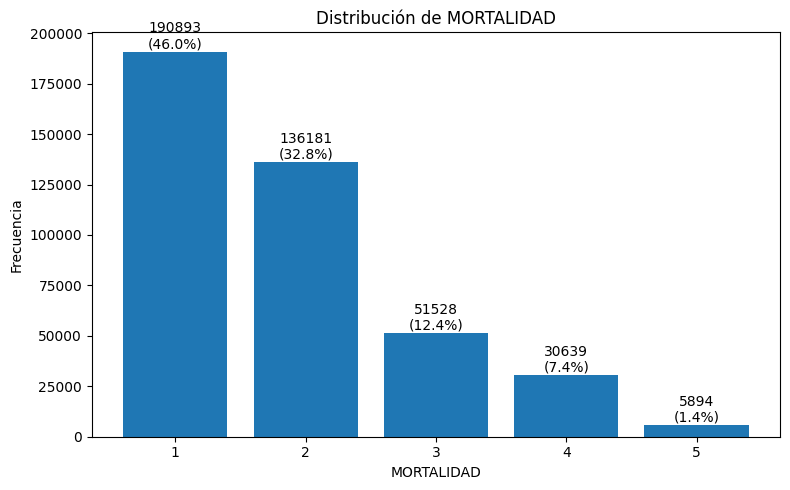

In [ ]:
#GRAFICAR VARIABLES CRITICAS ANTES DE ELIMINAR LOS DUPLICADOS
def graficar_categoricas(df, variables, colores=None):

    for variable in variables:

        frecuencias = df[variable].value_counts()
        porcentajes = df[variable].value_counts(normalize=True) * 100

        plt.figure(figsize=(8, 5))

        barras = plt.bar(
            frecuencias.index,
            frecuencias.values,
            color=colores
        )

        plt.title(f'Distribución de {variable}')
        plt.xlabel(variable)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=0)

        # Agregar frecuencia y porcentaje sobre cada barra
        for barra, frecuencia, porcentaje in zip(
            barras, frecuencias.values, porcentajes.values
        ):

            plt.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height(),
                f'{frecuencia}\n({porcentaje:.1f}%)',
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()

graficar_categoricas(df_paso1, ["CONTAGIOSA", "CRONICA", "MORTALIDAD"])

In [ ]:
#CORROBORAR QUE SE ELIMINARON LOS VALORES DUPLICADOS
df.duplicated().sum()

np.int64(54422)

Se evidencia que los cambios en la distribución porcentual de las frecuencias de las variables críticas se vió poco afectada por la eliminación de los datos duplicados, como se evidencia en las siguientes visualizaciones

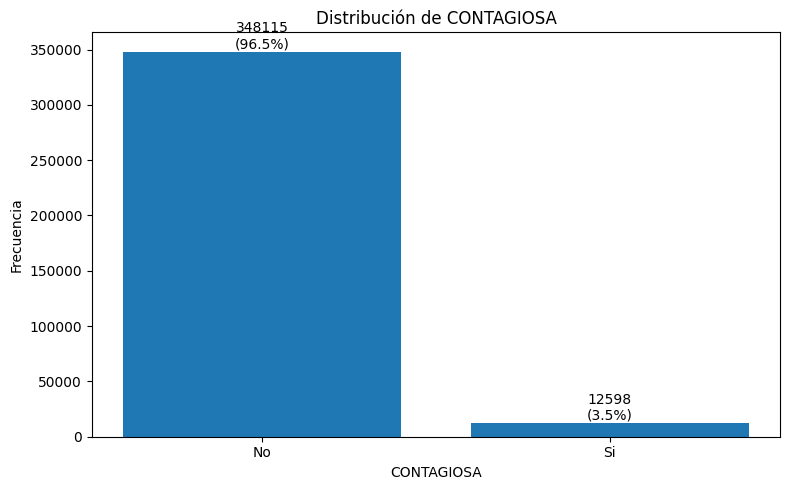

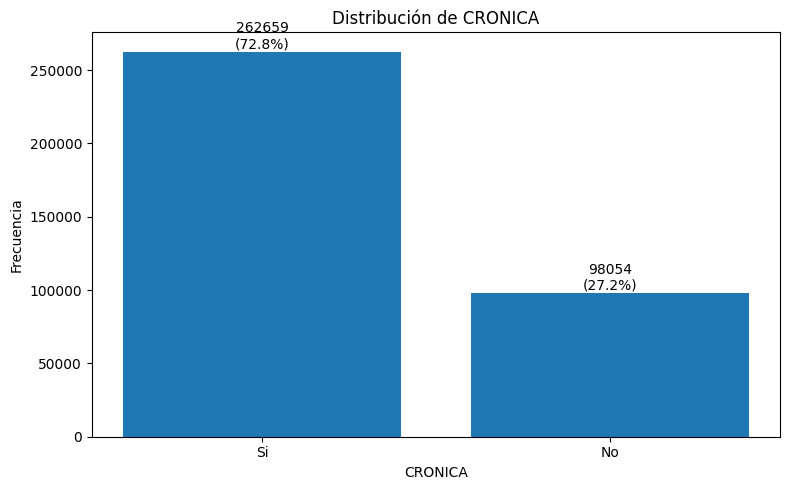

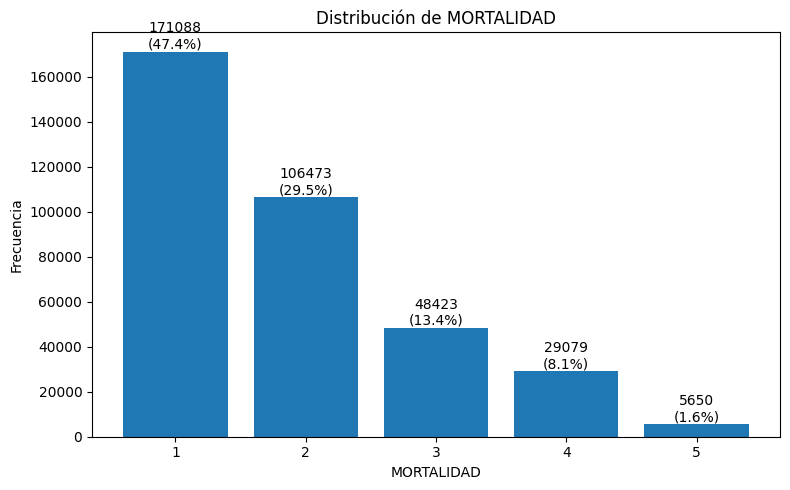

In [ ]:
#GRAFICAR VARIABLES CRITICAS DESPUES DE ELIMINAR LOS DUPLICADOS
def graficar_categoricas(df, variables, colores=None):

    for variable in variables:

        frecuencias = df[variable].value_counts()
        porcentajes = df[variable].value_counts(normalize=True) * 100

        plt.figure(figsize=(8, 5))

        barras = plt.bar(
            frecuencias.index,
            frecuencias.values,
            color=colores
        )

        plt.title(f'Distribución de {variable}')
        plt.xlabel(variable)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=0)

        # Agregar frecuencia y porcentaje sobre cada barra
        for barra, frecuencia, porcentaje in zip(
            barras, frecuencias.values, porcentajes.values
        ):

            plt.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height(),
                f'{frecuencia}\n({porcentaje:.1f}%)',
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()

graficar_categoricas(df_paso2, ["CONTAGIOSA", "CRONICA", "MORTALIDAD"])

Además de esto, tambien es necesario hacer un analisis de columnas repetidas o redundantes. La eliminación de columnas redundantes permite evitar la repetición de información, reducir posibles inconsistencias, disminuir la dimensionalidad del conjunto de datos y optimizar los procesos de análisis.

Dentro de nuestro dataset se observa que las columnas COD DIVIPOLA DEPARTAMENTO y DEPARTAMENTO contienen la misma información, la primera la brinda codificada y la segunda indica el nombre del departamento; caso similar para con las columnas COD DIVIPOLA MUN y MUNICIPIO. Para el analisis a relizar se ha decidido eliminar del conjunto de datos las columnas que poseen la informacion geografica codificada (COD DIVIPOLA DEPARTAMENTO y COD DIVIPOLA MUN)

In [ ]:
#ELIMINAR COLUMNAS REDUNDATES
df_paso2 = df_paso2.drop(columns=["COD DIVIPOLA DEPARTAMENTO", "COD DIVIPOLA MUN"])

### **1.3. Valores atípicos**
---
Al abordar valores atípicos, es relevante cuestionarse sobre la naturaleza de estos puntos extremos.

* ¿Son errores de medición o representan información válida pero excepcional?

Para los valores atipicos se decidio analizar la cantidad de pacientes atendidos en los municipios de residencia. Los valores atípicos identificados en la variable MUNICIPIO no se consideran inicialmente errores de medición, ya que corresponden a municipios reales de procedencia de los pacientes atendidos. Una baja frecuencia de pacientes provenientes de un municipio no implica que el registro sea incorrecto, sino que puede representar una ocurrencia válida pero poco frecuente dentro del conjunto de datos.

Por esta razón, los registros fueron considerados como valores atípicos desde una perspectiva de frecuencia de ocurrencia, y no necesariamente como errores en la información registrada.

* ¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?

Para identificar categorías con baja representación se calculó la frecuencia relativa de pacientes para cada municipio respecto al total de pacientes registrados. Se estableció un umbral de 1%, de manera que los municipios cuya frecuencia relativa se encontrara por debajo de dicho valor fueron clasificados como categorías atípicas.

Al calcularlo: de 98 municipios, 84 quedan por debajo del 1% y solo 14 (las principales ciudades: Cali, Barranquilla, Cartagena, Bogotá, Neiva, Buenaventura, Medellín, Bucaramanga, Santa Marta, Ibagué, Bello, Facatativá, Girardot y Armenia) lo superan. Esos 84 municipios "atípicos" concentran, en conjunto, 9,91% de las filas. Por ello, nos quedamos con los municipios que tienen volumen suficiente para sacar conclusiones

* ¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?

Se utilizó un método estadístico descriptivo basado en la distribución de frecuencias relativas de los pacientes según su municipio de procedencia, el análisis de frecuencias permite identificar municipios con una representación significativamente menor dentro del conjunto de datos.

* ¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?

Se decidió excluir del análisis los registros correspondientes a municipios cuya frecuencia relativa de pacientes se encuentre por debajo del 1% establecido.Esta decisión se tomó con el objetivo de concentrar el análisis en los municipios con una representación suficiente dentro de la población estudiada y evitar que categorías con una frecuencia extremadamente baja dificulten la interpretación de los resultados.


In [ ]:
#TABLA DE FRECUENCIAS PARA LOS MUNICIPIOS
tabla_frecuencias = (df_paso2['MUNICIPIO'].value_counts(normalize=True).reset_index())
tabla_frecuencias.columns = ['MUNICIPIO', 'FRECUENCIA_RELATIVA']
tabla_frecuencias['FRECUENCIA_RELATIVA'] *= 100
tabla_frecuencias

,MUNICIPIO,FRECUENCIA_RELATIVA
0,SANTIAGO DE CALI,21.012827
1,BARRANQUILLA,13.930188
2,CARTAGENA DE INDIAS,9.808629
3,"BOGOTÁ, D.C.",8.971398
4,NEIVA,8.698605
...,...,...
93,TABIO,0.000277
94,CALIMA,0.000277
95,VILLA DE LEYVA,0.000277
96,PIENDAMÓ - TUNÍA,0.000277


In [ ]:
#MUNICIPIOS CON FRECUENCIA RELATIVA MENOR DEL 1%
municipios_menor_1 = tabla_frecuencias[tabla_frecuencias['FRECUENCIA_RELATIVA'] < 1]
print(municipios_menor_1)

frecuencia_acumulada_menor_1 = municipios_menor_1[ 'FRECUENCIA_RELATIVA'].sum()
print(f"Frecuencia acumulada de municipios < 1%: {frecuencia_acumulada_menor_1:.2f}%")

              MUNICIPIO  FRECUENCIA_RELATIVA
14              PALMIRA             0.869389
15              PEREIRA             0.811448
16                TULUÁ             0.766815
17            LA DORADA             0.670062
18  GUADALAJARA DE BUGA             0.585507
..                  ...                  ...
93                TABIO             0.000277
94               CALIMA             0.000277
95       VILLA DE LEYVA             0.000277
96     PIENDAMÓ - TUNÍA             0.000277
97              BARANOA             0.000277

[84 rows x 2 columns]
Frecuencia acumulada de municipios < 1%: 9.91%


In [ ]:
#ELIMINAR LOS MUNICIPIOS CON FRECUENCIAS RELATIVAS <2%
df_paso3 = df_paso2[~df_paso2['MUNICIPIO'].isin(municipios_menor_1['MUNICIPIO'])]
print(f"Filas antes: {len(df_paso2)}  ->  después de excluir municipios atípicos: {len(df_paso3)} "
      f"(se eliminaron {len(df_paso2) - len(df_paso3)})")

Filas antes: 360713  ->  después de excluir municipios atípicos: 324979 (se eliminaron 35734)


In [ ]:
#CORROBORAR PASO ANTERIOR
df_paso3['MUNICIPIO'].value_counts(normalize=True) * 100

,proportion
MUNICIPIO,
SANTIAGO DE CALI,23.323353
BARRANQUILLA,15.461922
CARTAGENA DE INDIAS,10.887165
"BOGOTÁ, D.C.",9.957874
NEIVA,9.655085
BUENAVENTURA,5.964385
MEDELLÍN,5.924075
BUCARAMANGA,5.891458
SANTA MARTA,5.256340


### **1.4. Datos Inconsistentes**
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?

Dentro de la inspección de Inconsitencias se tuvieron en cuenta los siguientes casos:

-Deficiente estandarización: Se indago dentro del conjunto de datos con el fin de determinar datos con expresiones con errores en la estandarización, como por ejemplo aquellas enfermedades que tienen vocales con tílde quedan así: H?BITO

-Calidad en el formato fecha: se analizó la distribución de las fechas y horas de ingreso con el fin de encontrar anomalías

* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?

Si,aunque no suponen un nivel crítico dentro del conjunto de datos. En etapas posteriores tales como de visualización, este tipo de datos no podrían ser facilmente comprendidos, generado así confusión hacia el público objetivo de este análisis

* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?

Se ha generado un diccionario con todos los datos que no están estandarizados de manera correcta, con el fin de poderlos reemplazar en el dataframe

* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?

Se aseguró el mediante el uso del diccionario con el fin de generar los cambios correspondientes al dataframe, de igual forma, se genero una estandarización a nivel genera mediante las funciones .stripp y .upper, con el fin de que el conjunto de datos quede en óptimas condiciones

* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

Sí. Se automatizaron controles de calidad mediante expresiones regulares para confirmar la estandarizacion total de los nombres de las enfermedades y se aplicó una aserción lógica sobre las variables temporales para verificar que el 100% de los registros procesados pertenezcan exclusivamente al alcance del año 2025.


In [ ]:
df_paso4=df_paso3.copy()
df_paso4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324979 entries, 0 to 415153
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   FECHA REGISTRO   324979 non-null  datetime64[ns]
 1   DEPARTAMENTO     324979 non-null  object        
 2   MUNICIPIO        324979 non-null  object        
 3   CIE-10           324979 non-null  object        
 4   NOMBRE           324979 non-null  object        
 5   DESCRIPCION      324979 non-null  object        
 6   SISTEMA          324979 non-null  object        
 7   ENTIDAD REPORTA  324979 non-null  object        
 8   GRUPO            324979 non-null  object        
 9   CONTAGIOSA       324979 non-null  object        
 10  CRONICA          324979 non-null  object        
 11  MORTALIDAD       324979 non-null  object        
dtypes: datetime64[ns](1), object(11)
memory usage: 32.2+ MB


In [ ]:
fecha_parte = df_paso4['FECHA REGISTRO'].astype(str).str.split(' ').str[0]
df_paso4['HORA'] = df_paso4['FECHA REGISTRO'].astype(str).str.split(' ').str[1]


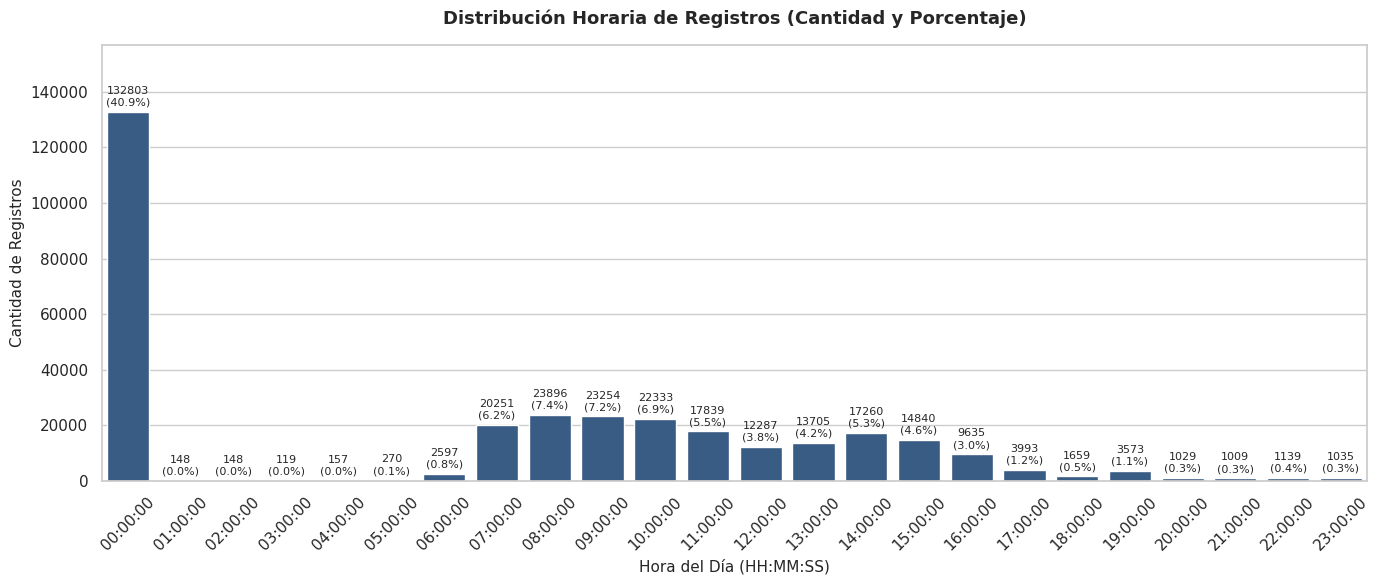

In [ ]:
# 1. Definir los 24 intervalos estándar (HH:MM:SS)
horas_24 = [f"{h:02d}:00:00" for h in range(24)]

# 2. Truncar la hora al inicio de cada intervalo
df_paso4['HORA_FORMATO'] = (
    pd.to_datetime(df_paso4['FECHA REGISTRO'])
    .dt.floor('h')
    .dt.strftime('%H:%M:%S')
)

# 3. Agrupar y reindexar para cubrir las 24 horas exactas
conteo_por_hora = (
    df_paso4.groupby('HORA_FORMATO')
    .size()
    .reindex(horas_24, fill_value=0)
    .reset_index(name='TOTAL_REGISTROS')
)
conteo_por_hora.rename(columns={'index': 'HORA_FORMATO'}, inplace=True)

# 4. Calcular el porcentaje relativo sobre el total global
total_general = conteo_por_hora['TOTAL_REGISTROS'].sum()
conteo_por_hora['PORCENTAJE'] = (conteo_por_hora['TOTAL_REGISTROS'] / total_general) * 100

# 5. Configurar y renderizar el gráfico
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

bars = sns.barplot(
    data=conteo_por_hora,
    x='HORA_FORMATO',
    y='TOTAL_REGISTROS',
    color='#2b5c8f'
)

plt.title('Distribución Horaria de Registros (Cantidad y Porcentaje)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (HH:MM:SS)', fontsize=11)
plt.ylabel('Cantidad de Registros', fontsize=11)
plt.xticks(rotation=45)

# 6. Añadir etiqueta combinada: Frecuencia Absoluta + Porcentaje
for p, pct in zip(bars.patches, conteo_por_hora['PORCENTAJE']):
    val = int(p.get_height())
    if val > 0:
        texto_etiqueta = f"{val}\n({pct:.1f}%)"
        bars.annotate(
            texto_etiqueta,
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=8, xytext=(0, 3),
            textcoords='offset points'
        )

# Ajustar límite Y para evitar que las etiquetas queden fuera de la imagen
plt.ylim(0, conteo_por_hora['TOTAL_REGISTROS'].max() * 1.18)

plt.tight_layout()
plt.show()

In [ ]:
# Identificar columnas de texto
cols_texto = df_paso4.select_dtypes(include=['object', 'string']).columns

hallazgos = []

def es_texto_corrupto(texto):
    texto_str = str(texto)
    if '?' in texto_str:
        partes = texto_str.split('?')
        for i in range(len(partes) - 1):
            parte_izq = partes[i]
            parte_der = partes[i + 1]
            if parte_izq and parte_der and parte_izq[-1].isalpha() and parte_der[0].isalpha():
                return True
    return False
for col in cols_texto:
    serie = df_paso4[col].dropna()
    mascara = serie.apply(es_texto_corrupto)
    afectados = serie[mascara]

    for val in afectados.unique():
        frecuencia = (serie == val).sum()
        hallazgos.append({
            'Columna': col,
            'Texto Corrupto': val,
            'Frecuencia': frecuencia
        })
df_inconsistencias = pd.DataFrame(hallazgos)
if not df_inconsistencias.empty:
    df_inconsistencias = df_inconsistencias.sort_values(by='Frecuencia', ascending=False).reset_index(drop=True)
    print(f"Total de registros verdaderamente corruptos: {len(df_inconsistencias)}")
else:
    print("No se encontraron textos corruptos.")
df_inconsistencias.head()

Total de registros verdaderamente corruptos: 7


,Columna,Texto Corrupto,Frecuencia
0,NOMBRE,SINDROME DE COLON IRRTABLE CON H?BITO INTESTIN...,194
1,NOMBRE,LINFOMA CENTRO FOLICULAR CUT?NEO,7
2,NOMBRE,LINFOMA ANGIOINMUNOBL?STICO DE CELULAS T,6
3,NOMBRE,ENFERMEDAD MIELODISPL?SICA Y MIELOPROLIFERATIV...,3
4,NOMBRE,OTROS TIPOS DE LINFOMAS DE HODGKIN CL?SICOS,3


In [ ]:
# Colocar Correciones al Texto
CORRECCIONES_TEXTO = {
    'SINDROME DE COLON IRRTABLE CON H?BITO INTESTINAL MIXTO [IBS-M]': 'SINDROME DE COLON IRRITABLE CON HÁBITO INTESTINAL MIXTO [IBS-M]',
    'LINFOMA CENTRO FOLICULAR CUT?NEO': 'LINFOMA CENTRO FOLICULAR CUTÁNEO',
    'LINFOMA ANGIOINMUNOBL?STICO DE CELULAS T': 'LINFOMA ANGIOINMUNOBLÁSTICO DE CELULAS T',
    'ENFERMEDAD MIELODISPL?SICA Y MIELOPROLIFERATIVA, NO CLASIFICADA EN OTRA PARTE': 'ENFERMEDAD MIELODISPLÁSICA Y MIELOPROLIFERATIVA, NO CLASIFICADA EN OTRA PARTE',
    'OTROS TIPOS DE LINFOMAS DE HODGKIN CL?SICOS': 'OTROS TIPOS DE LINFOMAS DE HODGKIN CLÁSICOS',
    'LINFOMA DE HODGKIN CL?SICO RICO EN LINFOCITOS': 'LINFOMA DE HODGKIN CLÁSICO RICO EN LINFOCITOS',
    'SINDROME DE RESPUESTA INFLAMATORIA SISTEMICA DE ORIGEN NO INFECCIOSO, CON FALLA ORG?NICA': 'SINDROME DE RESPUESTA INFLAMATORIA SISTEMICA DE ORIGEN NO INFECCIOSO, CON FALLA ORGÁNICA'
}
df_paso4['NOMBRE'] = df_paso4['NOMBRE'].replace(CORRECCIONES_TEXTO)


In [ ]:
# --- Regla de validación (¿el 100% de los registros son del 2025?) ---
fuera_2025 = df_paso4[df_paso4["FECHA REGISTRO"].dt.year != 2025]
print(f"\nRegistros fuera de 2025: {len(fuera_2025)} de {len(df_paso4)} ({len(fuera_2025)/len(df_paso4)*100:.3f}%)")
print(fuera_2025["FECHA REGISTRO"].dt.year.value_counts().sort_index())
try:
    assert len(fuera_2025) == 0, "La aserción 'todos los registros son de 2025' NO se cumple"
except AssertionError as e:
    print(f"\nResultado de la aserción: falla -> {e}")


Registros fuera de 2025: 38 de 324979 (0.012%)
FECHA REGISTRO
2023     3
2024     8
2026    27
Name: count, dtype: int64

Resultado de la aserción: falla -> La aserción 'todos los registros son de 2025' NO se cumple


In [ ]:
# Registros del año == 2025
df_paso4_2025 = df_paso4[df_paso4["FECHA REGISTRO"].dt.year == 2025]
print(f"Filas antes de filtrar por año: {len(df_paso4)}  ->  después: {len(df_paso4_2025)} "
      f"(se eliminaron {len(df_paso4) - len(df_paso4_2025)} registros fuera de 2025)")


Filas antes de filtrar por año: 324979  ->  después: 324941 (se eliminaron 38 registros fuera de 2025)


In [ ]:
df_paso4_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324941 entries, 0 to 415153
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   FECHA REGISTRO   324941 non-null  datetime64[ns]
 1   DEPARTAMENTO     324941 non-null  object        
 2   MUNICIPIO        324941 non-null  object        
 3   CIE-10           324941 non-null  object        
 4   NOMBRE           324941 non-null  object        
 5   DESCRIPCION      324941 non-null  object        
 6   SISTEMA          324941 non-null  object        
 7   ENTIDAD REPORTA  324941 non-null  object        
 8   GRUPO            324941 non-null  object        
 9   CONTAGIOSA       324941 non-null  object        
 10  CRONICA          324941 non-null  object        
 11  MORTALIDAD       324941 non-null  object        
 12  HORA             324941 non-null  object        
 13  HORA_FORMATO     324941 non-null  object        
dtypes: datetime64[ns](1), obj

In [ ]:
df_paso4_2025.head()

,FECHA REGISTRO,DEPARTAMENTO,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD,HORA,HORA_FORMATO
0,2025-01-07,ATLÁNTICO,BARRANQUILLA,M199,"ARTROSIS, NO ESPECIFICADA",OTRAS ARTROSIS,RIPS,INS,ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL T...,No,Si,1,00:00:00,00:00:00
1,2025-01-10,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1,00:00:00,00:00:00
2,2025-01-13,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1,00:00:00,00:00:00
3,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,INS,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1,00:00:00,00:00:00
4,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1,00:00:00,00:00:00


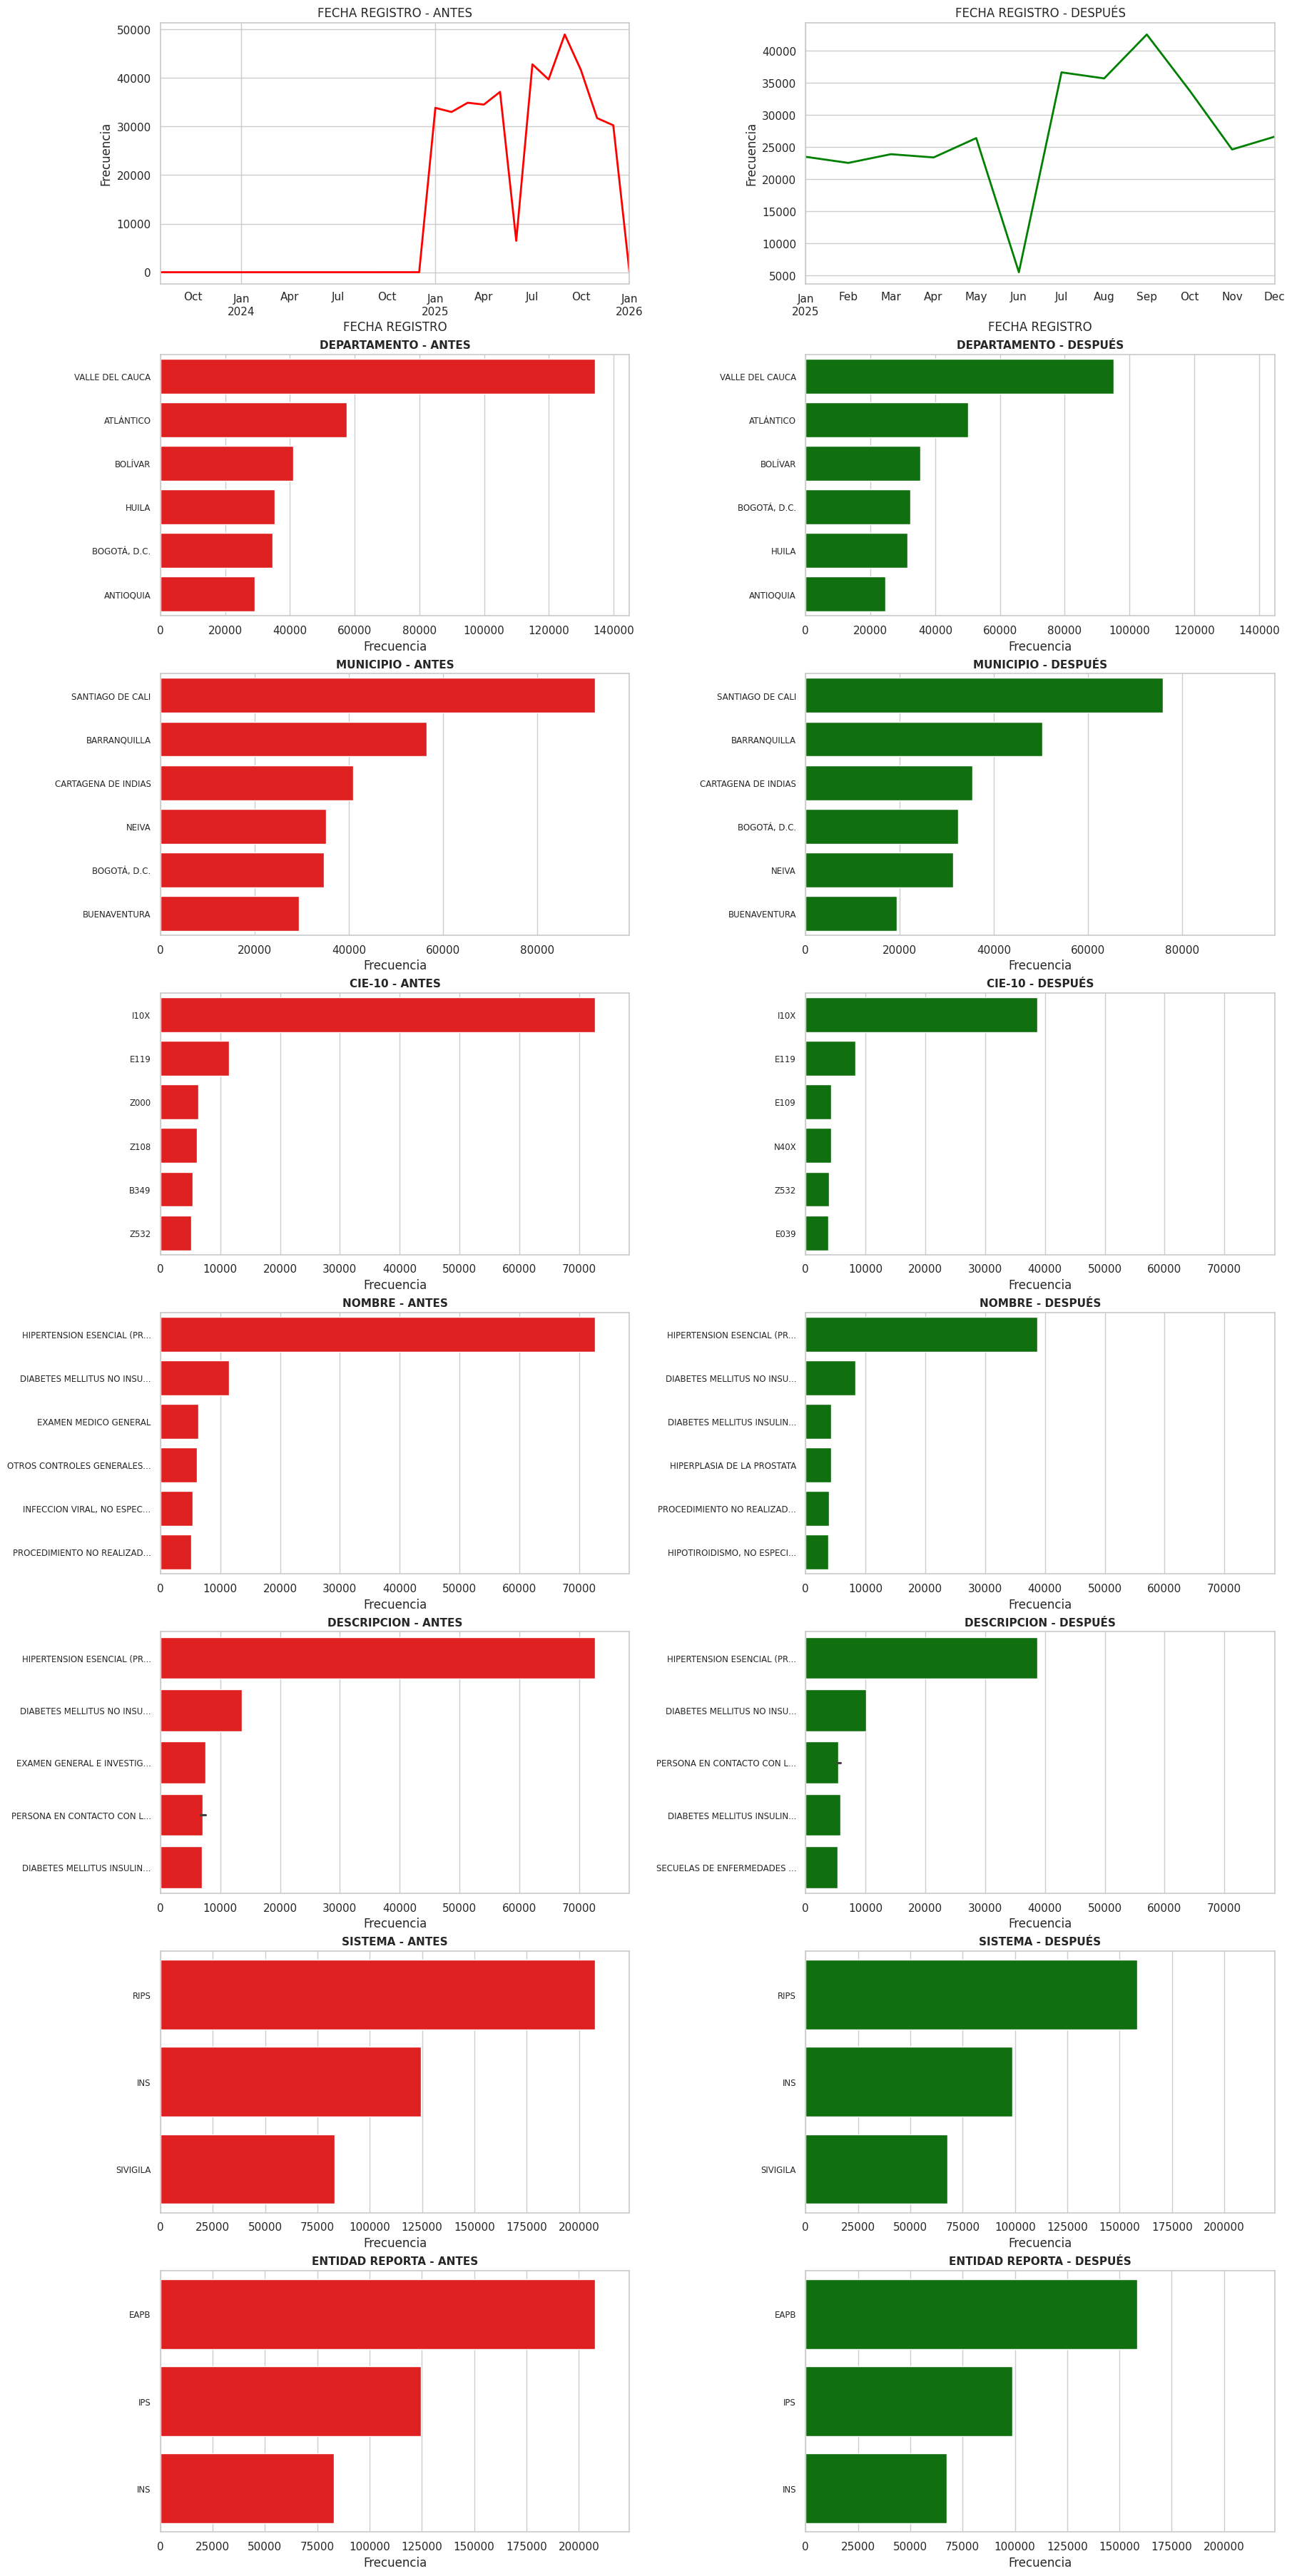

In [ ]:
# Creación de las gráficas comparativas entre el dataset original y el dataset compacto para las variables seleccionadas
class VisualizadorComparativo:
    def __init__(self, df_original: pd.DataFrame, df_paso4_2025: pd.DataFrame, top_n: int = 6):
        self.df_orig = df_original
        self.df_comp = df_paso4_2025
        self.top_n = top_n
        sns.set_theme(style="whitegrid")

    def _truncar_texto(self, serie: pd.Series, max_chars: int = 28) -> list:
        return [
            f"{str(label)[:max_chars - 3]}..." if len(str(label)) > max_chars else str(label)
            for label in serie.index
        ]

    def graficar_comparativa_variables(self, variables: list):
        n_vars = len(variables)
        fig, axes = plt.subplots(
            nrows=n_vars,
            ncols=2,
            figsize=(18, 4.5 * n_vars),
            constrained_layout=True
        )

        if n_vars == 1:
            axes = [axes]

        for idx, col in enumerate(variables):
            ax_antes, ax_despues = axes[idx][0], axes[idx][1]
            if pd.api.types.is_datetime64_any_dtype(self.df_orig[col]):
                self.df_orig.set_index(col).resample('ME').size().plot(
                    ax=ax_antes, color= 'red', lw=2, title=f'{col} - ANTES'
                )
                self.df_comp.set_index(col).resample('ME').size().plot(
                    ax=ax_despues, color= 'green', lw=2, title=f'{col} - DESPUÉS'
                )
                ax_antes.set_ylabel('Frecuencia')
                ax_despues.set_ylabel('Frecuencia')
            else:
                top_ant = self.df_orig[col].value_counts().head(self.top_n)
                top_des = self.df_comp[col].value_counts().head(self.top_n)

                max_x = max(
                    top_ant.max() if not top_ant.empty else 0,
                    top_des.max() if not top_des.empty else 0
                ) * 1.08
                sns.barplot(
                    x=top_ant.values,
                    y=self._truncar_texto(top_ant),
                    ax=ax_antes,
                    color= 'red'
                )
                ax_antes.set_title(f'{col} - ANTES', fontweight='bold', fontsize=11)
                ax_antes.set_xlim(0, max_x)
                ax_antes.set_xlabel('Frecuencia')
                ax_antes.tick_params(axis='y', labelsize=8.5)

                sns.barplot(
                    x=top_des.values,
                    y=self._truncar_texto(top_des),
                    ax=ax_despues,
                    color= 'green'
                )
                ax_despues.set_title(f'{col} - DESPUÉS', fontweight='bold', fontsize=11)
                ax_despues.set_xlim(0, max_x)
                ax_despues.set_xlabel('Frecuencia')
                ax_despues.tick_params(axis='y', labelsize=8.5)

        plt.show()

variables_analisis = [
    'FECHA REGISTRO', 'DEPARTAMENTO', 'MUNICIPIO', 'CIE-10',
    'NOMBRE', 'DESCRIPCION', 'SISTEMA', 'ENTIDAD REPORTA'
]
vis = VisualizadorComparativo(df, df_paso4_2025, top_n=6)
vis.graficar_comparativa_variables(variables_analisis)

### **1.5. Datos corruptos**
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?

Se realizó mediante la revisión de la consistencia y validez de los registros, detectando una observación cuyos valores no correspondían con la estructura y características esperadas para las variables del conjunto de datos (CODIGO CIE-10).
Aparte de esta novedad, no se evidenciaron casos adicionales a los ya tratados en puntos anteriores.

* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?

Debido a que el registro con código CIE-10 no correspondia al catalogo de códigos brindado por la OMS y que este registro tenía NOMBRE y DESCRIPCION vacíos en el archivo original, ya se había optado por eliminarlo del conjunto de datos (numeral 1.1.)

* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

No se identificaron otros casos de corrupción de datos que requirieran un tratamiento especial. El registro eliminado no pudo ser recuperado o corregido debido a que no existía información suficiente para determinar cuáles debían ser sus valores correctos.

In [ ]:
#REGISTROS CODIFICADOS ERRADAMENTE
df_filtrado = df_compacto[ df_compacto["CIE-10"].notna() & df_compacto["DESCRIPCION"].isna()]
df_filtrado

,FECHA REGISTRO,COD DIVIPOLA DEPARTAMENTO,DEPARTAMENTO,COD DIVIPOLA MUN,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD
185050,2025-08-13 10:15:00,11,"BOGOTÁ, D.C.",11001,"BOGOTÁ, D.C.",N39X,NaN,NaN,RIPS,IPS,NaN,NaN,NaN,NaN


In [ ]:
# Confirmar que la fila de N39X es la misma que ya se contó en 1.1
fila_n39x = df_compacto[df_compacto["CIE-10"] == "N39X"]
print("\nLa fila con N39X:")
print(fila_n39x[["FECHA REGISTRO", "MUNICIPIO", "CIE-10", "NOMBRE", "DESCRIPCION"]])
print("\n¿Esta fila ya fue eliminada en el paso 1 (faltantes)?",
      "Sí" if fila_n39x.index[0] not in df_paso1.index else "No")


La fila con N39X:
            FECHA REGISTRO     MUNICIPIO CIE-10 NOMBRE DESCRIPCION
185050 2025-08-13 10:15:00  BOGOTÁ, D.C.   N39X    NaN         NaN

¿Esta fila ya fue eliminada en el paso 1 (faltantes)? Sí




### **1.6. Selección de datos**
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?

1.Importancia Analitica:¿La variable aporta infomación para los análisis posteriores según el contexto del dataset?

2.Redudancia : ¿La variable es una derivación de otra columna existente?

3.Calidad de los datos : ¿ La variable mantiene un nivel aceptable de integridad posterior a la etapa de limpieza?

* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?

No se usó muestreo aleatorio, pero sí se aplicó un filtro de alcance (excluir municipios con menos del 1% de frecuencia), además de la eliminación de faltantes y duplicados, el volumen del dataset (324.941) es computacionalmente manejable y permite un análisis sin perder objetividad

* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?

La inclusión de los datos corresponde a los criterios uno y tres mencionados anteriormente, la mayoría de las columnas del dataset cumplen con este criterio. En cuanto a los casos de exclusión, corresponden  a columnas que no generan un análisis lo suficientemente contudente dentro de etapas posteriores, tales como los códo Divipola(código de división administrativa), aunque son códigos únicos, genera una redudancia, debido a que las columnas de municipio y departamento pueden generar conclusiones, además de una manera mucho más clara y accesible hacia el público objetivo. Igualmente, se excluye las columnas calculadas de Hora,hora_formato debido a que no generan la suficiente imporancia con el fin de poder generar insigths. En el caso de la hora, los eventos en salud son eventos con hora especifica, sin, embargo, la hora está ausente o poco confiable en casi la mitad de los registros; el 47% tienen exactamente 00:00:00 lo cual se deja como observación para su validación en la fuente de los datos. En cuanto al año, debido a que son eventos de 2025, la columna deja de tener relevancia más allá de etapas de limpieza.

In [ ]:
# --- Verificación del tamaño final del dataset limpio ---
print("Resumen del pipeline de limpieza:")
print(f"  0. Filas iniciales:                         {len(df_compacto)}")
print(f"  1. Tras eliminar faltantes (19):            {len(df_paso1)}")
print(f"  2. Tras eliminar duplicados (54.422):       {len(df_paso2)}")
print(f"  3. Tras excluir municipios atípicos:        {len(df_paso3)}")
print(f"  4. Tras corregir texto y filtrar año 2025:  {len(df_paso4_2025)}")


Resumen del pipeline de limpieza:
  0. Filas iniciales:                         415154
  1. Tras eliminar faltantes (19):            415135
  2. Tras eliminar duplicados (54.422):       360713
  3. Tras excluir municipios atípicos:        324979
  4. Tras corregir texto y filtrar año 2025:  324941


In [ ]:
df_paso4_2025 = df_paso4_2025.drop(columns=["HORA", "HORA_FORMATO"])

In [ ]:
# --- Dataset final de esta etapa (14 columnas originales, sin las DIVIPOLA, filas ya limpias) ---
columnas_finales = [
    "FECHA REGISTRO", "DEPARTAMENTO", "MUNICIPIO", "CIE-10", "NOMBRE", "DESCRIPCION",
    "SISTEMA", "ENTIDAD REPORTA", "GRUPO", "CONTAGIOSA", "CRONICA", "MORTALIDAD",
]
df_final = df_paso4_2025[columnas_finales].reset_index(drop=True)
print("Dataset final:", df_final.shape)
df_final.head()

Dataset final: (324941, 12)


,FECHA REGISTRO,DEPARTAMENTO,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD
0,2025-01-07,ATLÁNTICO,BARRANQUILLA,M199,"ARTROSIS, NO ESPECIFICADA",OTRAS ARTROSIS,RIPS,INS,ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL T...,No,Si,1
1,2025-01-10,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
2,2025-01-13,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
3,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,INS,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
4,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324941 entries, 0 to 324940
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   FECHA REGISTRO   324941 non-null  datetime64[ns]
 1   DEPARTAMENTO     324941 non-null  object        
 2   MUNICIPIO        324941 non-null  object        
 3   CIE-10           324941 non-null  object        
 4   NOMBRE           324941 non-null  object        
 5   DESCRIPCION      324941 non-null  object        
 6   SISTEMA          324941 non-null  object        
 7   ENTIDAD REPORTA  324941 non-null  object        
 8   GRUPO            324941 non-null  object        
 9   CONTAGIOSA       324941 non-null  object        
 10  CRONICA          324941 non-null  object        
 11  MORTALIDAD       324941 non-null  object        
dtypes: datetime64[ns](1), object(11)
memory usage: 29.7+ MB


In [ ]:
df_final.to_csv("dataset_final.csv")

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*